# AG-HYPOPT · Trial 10

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

[Nine trials recorded; best is trial 09 (0.0182). Sequence: 01 0.0981, 02 0.0246, 03 0.0477, 04 0.0262, 05 0.0196, 06 0.0329, 07 0.0205, 08 0.0294, 09 0.0182. Trials 05/07/08/09 are all the same plateau point (lr_mu ~27, sigma_ref ~6.2, lr_gamma ~0.42, gamma_anneal ~0.39) with mu stuck at 14.4-15.6%; their objectives differ (0.0182-0.0294) mainly through the low-count Trans05 gamma noise, and trial 09 landed on the favourable side. So the search has converged: mu is a stable function of (lr_mu ~27, sigma_ref ~6.2), and no tunable has moved gamma beyond noise. lr_mu peaks near 27 and sigma_ref is monotone (smaller better, saturated below ~6.3). We are in the TPE phase (10th trial).]


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_10'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 20    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (9/5 trials)
ID |     ei | params
 1 | 3.9999 | {"gamma_anneal": 0.40692152267967024, "lr_gamma": 0.41740326658737814, "lr_mu": 27.063926126488244, "sigma_ref": 6.332122953119211}
 2 | 3.9999 | {"gamma_anneal": 0.3839565017149634, "lr_gamma": 0.4164227481816149, "lr_mu": 27.057894781100057, "sigma_ref": 6.221035453931963}
 3 | 0.2958 | {"gamma_anneal": 0.5591851582829531, "lr_gamma": 0.9252230048903416, "lr_mu": 26.330993747640157, "sigma_ref": 24.396607364126435}
 4 | 2.2226 | {"gamma_anneal": 0.3651237698069035, "lr_gamma": 0.6846919966557408, "lr_mu": 27.081001826118857, "sigma_ref": 9.995510387925663}
 5 | 3.6366 | {"gamma_anneal": 0.391821616296292, "lr_gamma": 0.3195319204647906, "lr_mu": 11.223023439787408, "sigma_ref": 6.188809787773774}
 6 | 4.0000 | {"gamma_anneal": 0.413237748669919, "lr_gamma": 0.41830206400110437, "lr_mu": 27.076746481099203, "sigma_ref": 6.236911549052799}
 7 | 3.9867 | {"gamma_anneal": 0.3721504463617422, "lr_gamma": 0.8137928136309818, "

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

[Best is trial 09 (0.0182); trials 05/07/08/09 are the same plateau config with objective differences from Trans05 gamma noise. The TPE batch once more clusters on the plateau: #6 (ei 4.0000), #2 and #1 (both 3.9999) are effectively identical points at lr_mu ~27, sigma_ref ~6.2, lr_gamma ~0.42, gamma_anneal ~0.39, and #7 (ei 3.9867) is the same apart from lr_gamma 0.81. With the plateau established, the most defensible choice is the model's single highest-ei draw, candidate 6 (lr_mu 27.08, sigma_ref 6.237, lr_gamma 0.418, gamma_anneal 0.413), i.e. the optimum point, to accumulate another sample of the floor. Candidate 7 (lr_gamma 0.81) would probe the gamma direction, but high lr_gamma already hurt throughout the campaign (trials 03/04), so it is the weaker bet. I choose candidate 6.]


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 6               # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.413237748669919, 'lr_gamma': 0.41830206400110437, 'lr_mu': 27.076746481099203, 'sigma_ref': 6.236911549052799}
Running  1nW Trans05 ... 

μ 9.39 -> 6.87 | γ 8.5 -> 6.85 | NLL 1.33


Running  1nW Trans20 ... 

μ 17.32 -> 15.87 | γ 8.5 -> 8.10 | NLL 2.73


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 99.30 | γ 14.1 -> 13.95 | NLL 3.35


Running 3nW Trans100 ... 

μ 175.71 -> 156.65 | γ 14.1 -> 13.96 | NLL 2.98



Total: 7.1 min


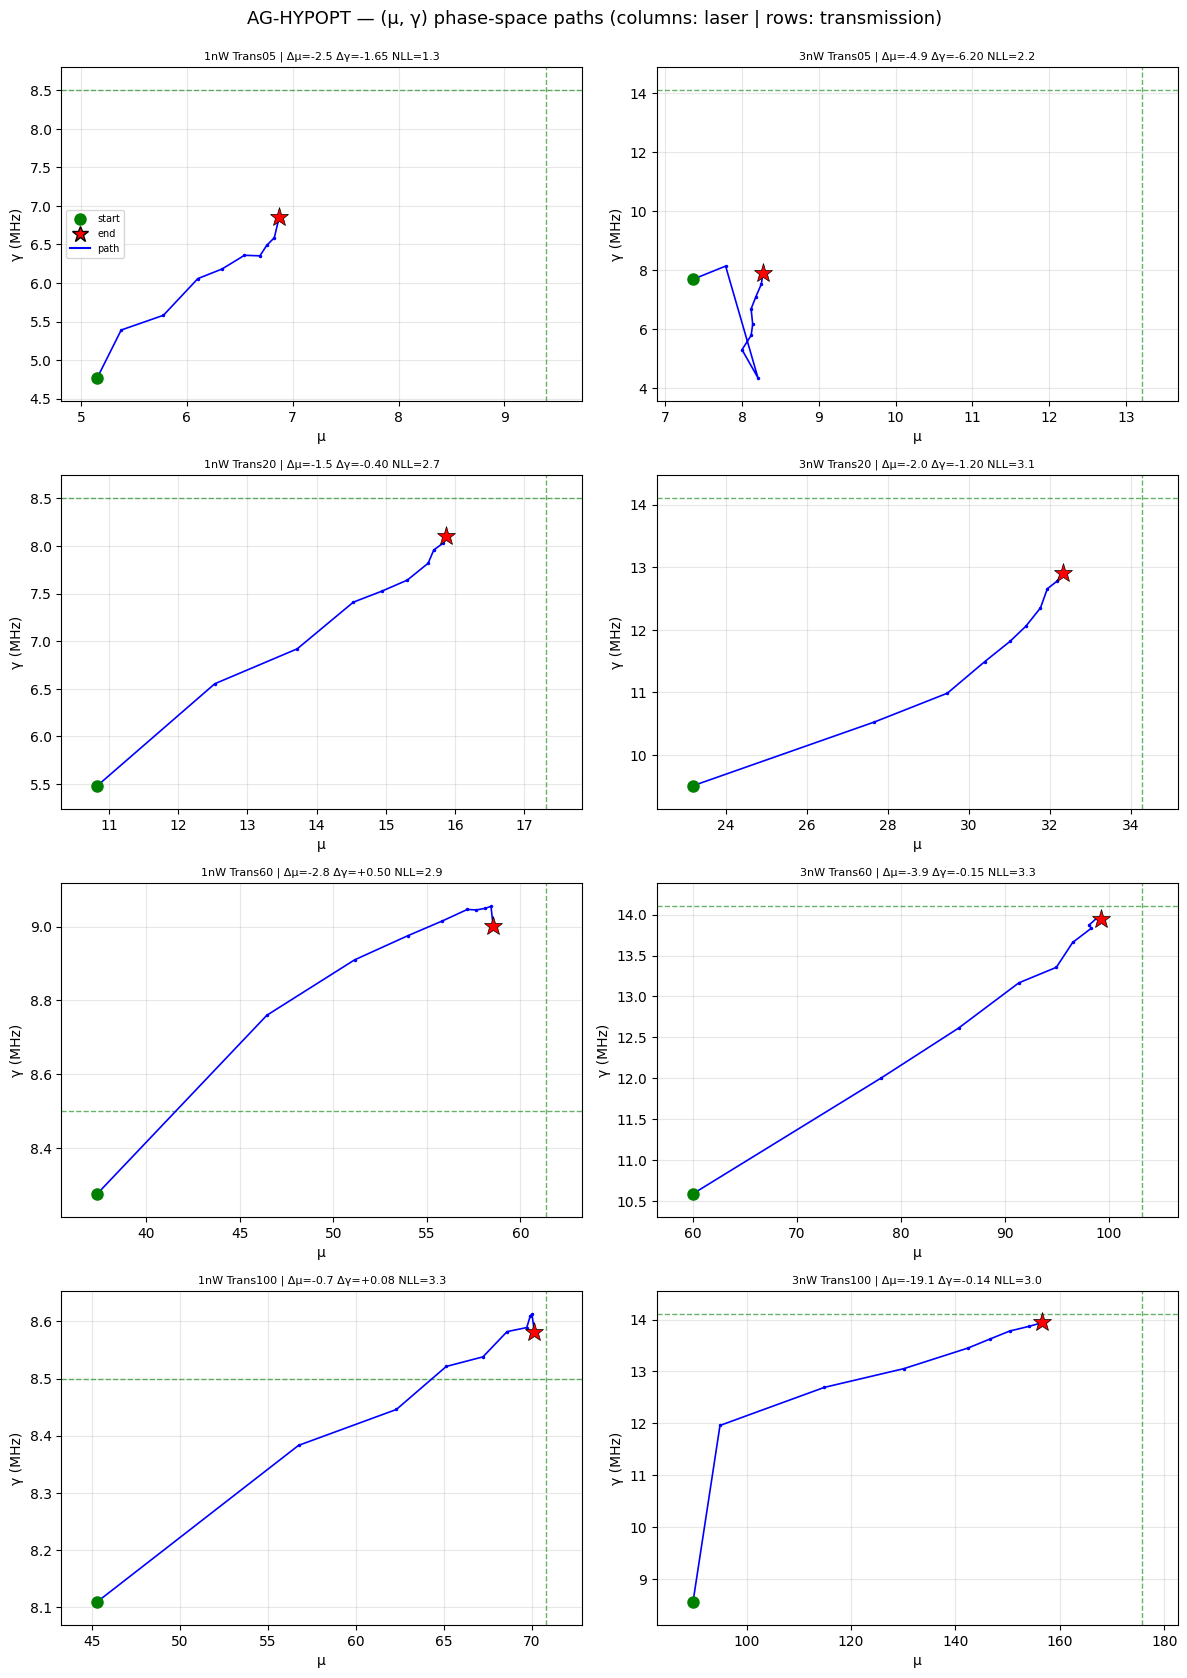

trial finished in 7.1 min
objective = 0.0301 ± 0.0143
exp           μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05     9.39    6.87   -26.8 |     8.50    6.85   -19.4
1nW Trans20    17.32   15.87    -8.4 |     8.50    8.10    -4.7
1nW Trans60    61.37   58.55    -4.6 |     8.50    9.00    +5.9
1nW Trans100   70.82   70.15    -0.9 |     8.50    8.58    +1.0
3nW Trans05    13.20    8.27   -37.4 |    14.10    7.90   -43.9
3nW Trans20    34.28   32.32    -5.7 |    14.10   12.90    -8.5
3nW Trans60   103.20   99.30    -3.8 |    14.10   13.95    -1.1
3nW Trans100  175.71  156.65   -10.8 |    14.10   13.96    -1.0

μ: RMSE 7.274 (rel 17.2%, bias -4.663) | γ: RMSE 2.319 (rel 17.5%, bias -1.144)


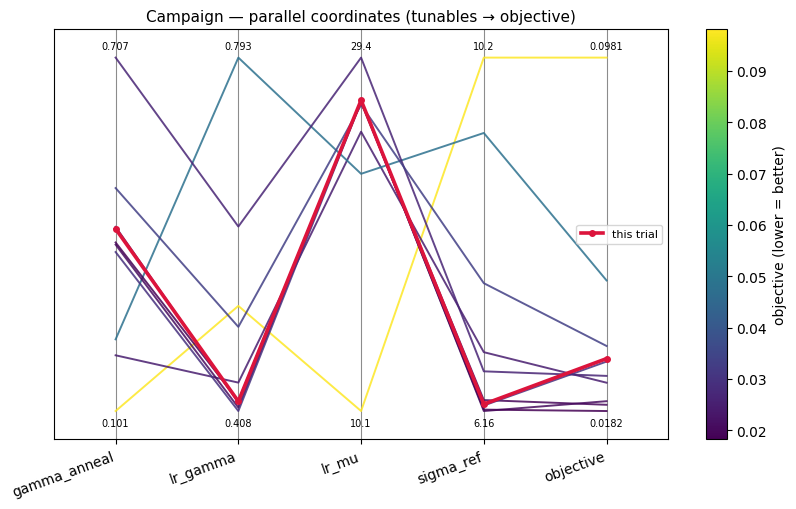

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 10 (sigma_ref 6.24, lr_mu 27.08, lr_gamma 0.418, gamma_anneal 0.413) is essentially trial 09's config (differences below 0.1 in every parameter) and scored 0.0301 +/- 0.0143 versus trial 09's 0.0182 - a 65% swing between two nearly identical configs. mu is 17.2% here (vs 14.4% in 09; the 3nW Trans05 point regressed to -37.4%) and gamma is 17.5% (vs 12.5%; 3nW Trans05 gamma -43.9%). This is the clearest demonstration yet that, on the plateau, the objective is dominated by the stochastic low-count Trans05 scans: the same (lr_mu ~27, sigma_ref ~6.2) point produces mu 14.4-17.2% and gamma 12.5-17.5% across runs. Trial 09 remains best, and no tunable value has reproduced a mu below ~14.4%.

**Summary:** Trial 10 (sigma_ref 6.24, lr_mu 27.08, lr_gamma 0.418, gamma_anneal 0.413), essentially identical to trial 09, scored 0.0301 +/- 0.0143 versus trial 09's 0.0182 - a 65% swing proving the plateau objective is dominated by Trans05 gamma noise.
**Key insight:** Near-identical plateau configs differ by up to ~65% in objective (0.018-0.030) purely through the low-count Trans05 runs; the true floor is ~0.018 and no hyperparameter value has beaten it.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
[Notes for Anuar: none this trial.]


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 10 (sigma_ref 6.24, lr_mu 27.08, lr_gamma 0.418, gamma_anneal 0.413), essentially identical to trial 09, scored 0.0301 +/- 0.0143 versus trial 09 0.0182 - a 65% swing proving the plateau objective is dominated by Trans05 gamma noise.'
KEY_INSIGHT = 'Near-identical plateau configs differ by up to ~65% in objective (0.018-0.030) purely through the low-count Trans05 runs; the true floor is ~0.018 and no hyperparameter value has beaten it.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_10 | current best: trial_09


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_11.ipynb. Open it and follow its cells from the top.
